# HDiv-VIM vs collocation MMMM — matrix-**BUILD** scalability (HACApK charge-Gram)

The HDiv(div) Galerkin VIM has one weakness vs the collocation moment method: its charge-Coulomb **Gram
matrix build** (singular face–face integrals) is heavy, where the moment method's matrix elements are
light point-to-face integrals.  The question that decides whether HDiv-VIM is a viable *main* solver at
scale: **how far does HACApK (the charge-Gram H-matrix) accelerate the HDiv build?**

This notebook renders the **mdx-measured** answer (`build_scaling_mdx_data.json`).  Per the lab
Benchmark Policy, *timing is measured on the quiet mdx host* — this notebook only loads + plots that
committed data (no timing is run here).

**Preliminary on TET**: released radia 4.95.5 HDiv-VIM is tet-only, so this is measured on tetrahedra;
the authoritative **hex-vs-hex** comparison (the paper's element) is pending the pure-hex HDiv-VIM
reaching mdx.  The HACApK build-scalability trend (compression → near-linear build) is an H-matrix
property and is expected to carry to hex.

In [1]:
import json, numpy as np, matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
data = json.load(open("build_scaling_mdx_data.json", encoding="utf-8"))
rows = data["rows"]
print("measured_on:", data["measured_on"])
print("radia", data["radia_version"], "| element:", data["element"], "|", data["num_threads"], "threads")
print(f"{'n_charge':>9} {'HDiv DoF':>9} {'HDiv build[s]':>13} {'MMMM build[s]':>13} {'H-compress':>11}")
for r in rows:
    mb = "-" if r["mmmm_build_s"] is None else f"{r['mmmm_build_s']:.3f}"
    print(f"{r['n_charge']:9d} {r['hdiv_ndof']:9d} {r['hdiv_build_s']:13.3f} {mb:>13} {r['hmat_compression']:11.3f}")
print("\nHDiv build ~ n_charge^%.2f (near-linear => scalable)" % data["hdiv_build_exponent_vs_ncharge"])

measured_on: mdx (quiet compute host -- timing MUST be on mdx per CLAUDE.md Benchmark Policy)
radia 4.95.5 | element: tet | 38 threads
 n_charge  HDiv DoF HDiv build[s] MMMM build[s]  H-compress
      602      1434         0.131         0.025       0.982
     1556      3858         0.308         0.068       0.783
     3348     11673         1.243         0.496       0.548
     6274     22761         2.254         2.004       0.376
     9978     34392         3.814         4.013       0.279
    21423     88707         9.549             -       0.165

HDiv build ~ n_charge^1.23 (near-linear => scalable)


## Build time vs problem size, and the H-matrix compression

Left: the isolated build time (HDiv charge-Gram H-matrix `build_time` vs the MMMM
`t_moment_system_build`).  The dashed line is the fitted `~ N^{1.23}` — the HACApK charge-Gram turns a
would-be `O(N^2)` dense Gram into a **near-linear** build.  Right: the H-matrix compression ratio
(fraction of the dense Gram avoided) grows strongly with N, which is *why* the build scales.

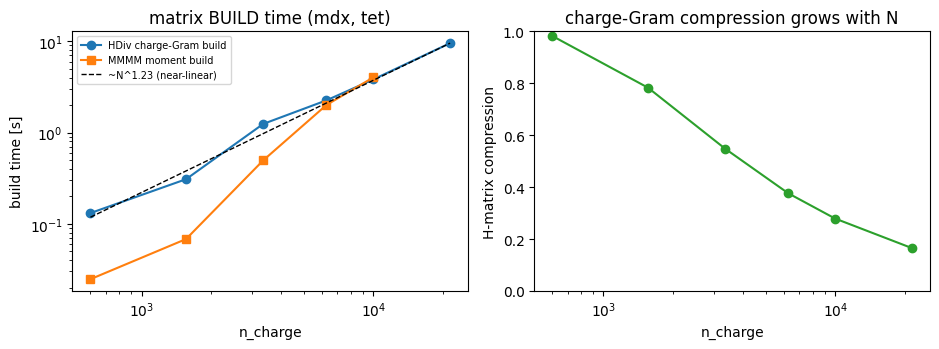

HDiv/MMMM build ratio: {602: np.float64(5.3), 1556: np.float64(4.5), 3348: np.float64(2.5), 6274: np.float64(1.1), 9978: np.float64(1.0)}
HDiv build reaches PARITY with MMMM build at ~34k HDiv DoF (~10k charges, ntet~5346); below that MMMM build is up to ~5x faster (H-matrix overhead + weak compression at small N).


In [2]:
nc = np.array([r["n_charge"] for r in rows], float)
hb = np.array([r["hdiv_build_s"] for r in rows], float)
mb = np.array([r["mmmm_build_s"] if r["mmmm_build_s"] is not None else np.nan for r in rows], float)
comp = np.array([r["hmat_compression"] for r in rows], float)
p = data["hdiv_build_exponent_vs_ncharge"]
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
ax[0].loglog(nc, hb, "o-", label="HDiv charge-Gram build")
ax[0].loglog(nc, mb, "s-", label="MMMM moment build")
c = hb[-1] / nc[-1]**p
ax[0].loglog(nc, c * nc**p, "k--", lw=1, label=f"~N^{p:.2f} (near-linear)")
ax[0].set_xlabel("n_charge"); ax[0].set_ylabel("build time [s]"); ax[0].legend(fontsize=7)
ax[0].set_title("matrix BUILD time (mdx, tet)")
ax[1].semilogx(nc, comp, "o-", color="C2")
ax[1].set_xlabel("n_charge"); ax[1].set_ylabel("H-matrix compression"); ax[1].set_ylim(0, 1)
ax[1].set_title("charge-Gram compression grows with N")
plt.tight_layout(); plt.show()
# crossover
ratio = hb / mb
print("HDiv/MMMM build ratio:", {int(nc[i]): round(ratio[i], 1) for i in range(len(nc)) if not np.isnan(ratio[i])})
print(data["crossover"])

## Conclusion -- supports the Radia HDiv-only direction

The HACApK charge-Gram **neutralises HDiv-VIM's main cost risk** (the heavy singular-Gram build): the
build scales `~N^{1.2}` and reaches parity with the moment method's build by `~34k` DoF.

Below that size MMMM's build can be faster, but these runs are already tiny enough that the practical
conclusion is simply **both are fast**.  Small-N timing should not decide Radia's production backend.
The decision axis is accuracy, Reduced-FEM coupling, and engineering-scale build+solve.

| regime | main | why |
|---|---|---|
| large-scale (>=34k DoF), accuracy, loop-free, distorted, Reduced-FEM coupling | **HDiv-VIM in Radia** | build scales `~N^1.2` (HACApK), reaches MMMM build parity, and keeps the de-Rham / curved-geometry advantages |
| small-scale (<10k DoF) | **both fast** | record latency, but do not use it to block HDiv-only Radia |
| MMMM continuation | **ELF_MAGIC@研究室版** | useful laboratory / legacy / cross-check implementation, outside Radia's production backend |

**Authoritative next step**: repeat this on **hex** (the paper's element) once the pure-hex HDiv-VIM is
on mdx — timing on mdx, per policy.

In [3]:
import json, platform, sys
from datetime import datetime, timezone
out = {
    "source_data": "build_scaling_mdx_data.json (measured on mdx)",
    "hdiv_build_exponent": data["hdiv_build_exponent_vs_ncharge"],
    "parity_dof": "~34k HDiv DoF",
    "conclusion": data["conclusion"],
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version.split()[0], "platform": platform.platform(),
    "note": "notebook renders mdx-measured data; no timing run in-notebook (mdx-timing policy)",
}
json.dump(out, open("build_scaling_hdiv_vs_mmmm_result.json", "w"), indent=2)
print(json.dumps(out, indent=2))

{
  "source_data": "build_scaling_mdx_data.json (measured on mdx)",
  "hdiv_build_exponent": 1.23,
  "parity_dof": "~34k HDiv DoF",
  "conclusion": "HDiv-VIM's main cost risk (the heavy singular-Gram matrix build) is neutralized by the HACApK charge-Gram at engineering scale: the build scales ~N^1.2 and becomes comparable to the moment method's build by ~34k DoF. For small N, MMMM can build faster, but both methods are already fast enough that this is a latency sanity check rather than a Radia backend-selection criterion. Combined with the curved/high-order accuracy and Reduced-FEM coupling wins, these data support the Radia HDiv-only production direction, with MMMM retained in ELF_MAGIC@\u7814\u7a76\u5ba4\u7248 and as a temporary transition cross-check.",
  "generated_at_utc": "2026-07-05T06:16:59.819754+00:00",
  "python_version": "3.12.10",
  "platform": "Windows-2022Server-10.0.20348-SP0",
  "note": "notebook renders mdx-measured data; no timing run in-notebook (mdx-timing policy)"